# Análisis de rendimiento de bots

## Librerias

In [34]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
import numpy as np
import re
import sys

## Constantes

In [35]:
# Directorios
BASE_DIR = Path.cwd()
LOG_DIR = BASE_DIR / "historiales"
OUTPUT_DIR = BASE_DIR / "resultados_analisis"
OUTPUT_DIR.mkdir(exist_ok=True)

# Métricas
METRICAS = ["VPIP", "PFR", "3Bet", "WTSD", "WSD", "WWSF"]
TIPOS_BOT = ["BOT_LLM", "BOT_NN", "BOT_FSM"]
ESTILOS = [
    "TIGHT_PASSIVE",
    "TIGHT_AGGRESSIVE",
    "LOOSE_PASSIVE",
    "LOOSE_AGGRESSIVE",
    "MANIAC",
    "DEFAULT",
]
NOMBRES_ESTILOS = {
    "TIGHT_PASSIVE": "Tight Passive",
    "TIGHT_AGGRESSIVE": "Tight Aggressive",
    "LOOSE_PASSIVE": "Loose Passive",
    "LOOSE_AGGRESSIVE": "Loose Aggressive",
    "MANIAC": "Maniac",
    "DEFAULT": "Default",
}

## Funciones de lectura de logs

In [36]:
# ============================================================
# FUNCIONES DE LECTURA
# ============================================================
def extraer_campo(linea, campo):
    patron = rf"^{re.escape(campo)}\.*\s+(.+)$"
    resultado = re.match(patron, linea.strip(), re.IGNORECASE)

    if resultado:
        return resultado.group(1).strip()

    return None


def convertir_si_no(valor):
    if valor is None:
        return np.nan

    return 1 if valor.strip().upper() == "YES" else 0


def normalizar_tipo(valor):
    if valor is None:
        return None

    return valor.strip().upper()


def normalizar_estilo(valor):
    """
    IMPORTANTE:
    El estilo se obtiene SIEMPRE del campo Style del bloque
    *** EXPERIMENT ***.

    Mapeo exacto de getPlayerStyle():

        DEFAULT -> DEFAULT
        TP      -> TIGHT_PASSIVE
        TAG     -> TIGHT_AGGRESSIVE
        LP      -> LOOSE_PASSIVE
        LAG     -> LOOSE_AGGRESSIVE
        MANIAC  -> MANIAC
    """

    if valor is None:
        return None

    equivalencias = {
        "DEFAULT": "DEFAULT",
        "TP": "TIGHT_PASSIVE",
        "TAG": "TIGHT_AGGRESSIVE",
        "LP": "LOOSE_PASSIVE",
        "LAG": "LOOSE_AGGRESSIVE",
        "MANIAC": "MANIAC",
    }

    return equivalencias.get(valor.strip().upper(), valor.strip().upper())


def parsear_hand(path):

    texto = path.read_text(encoding="utf-8", errors="replace")
    lineas = texto.splitlines()

    match_id = path.parent.name
    hand_match = re.search(r"hand_(\d+)\.log$", path.name, re.IGNORECASE)
    hand_id = int(hand_match.group(1)) if hand_match else None

    jugadores = []
    actual = None
    en_experiment = False

    # ========================================================
    # BLOQUE EXPERIMENT
    # ========================================================
    for linea in lineas:
        s = linea.strip()

        if s == "*** EXPERIMENT ***":
            en_experiment = True
            continue

        if not en_experiment:
            continue

        if s.startswith("--------- PLAYER"):
            if actual is not None:
                jugadores.append(actual)

            actual = {
                "Match": match_id,
                "Hand": hand_id,
                "File": path.name,
                "Player": None,
                "PlayerId": None,
                "Type": None,
                "Model": None,
                "Style": None,
                "Position": None,
                "Initial stack": np.nan,
                "Final stack": np.nan,
                "VPIP": np.nan,
                "PFR": np.nan,
                "3Bet": np.nan,
                "WTSD": np.nan,
                "WSD": np.nan,
                "WWSF": np.nan,
                # Acciones para calcular AF:
                "Calls": 0,
                "Bets": 0,
                "Raises": 0,
                "Folds": 0,
                "Checks": 0,
                "AllIns": 0,
            }

            continue

        if actual is None:
            continue

        # ----------------------------------------------------
        # Campos básicos
        # ----------------------------------------------------

        campos = [
            "Player",
            "PlayerId",
            "Type",
            "Model",
            "Style",
            "Position",
            "Initial stack",
            "Final stack",
            "Hand result",
        ]

        encontrado = False

        for campo in campos:
            valor = extraer_campo(s, campo)

            if valor is None:
                continue

            if campo == "PlayerId":
                try:
                    valor = int(valor)
                except ValueError:
                    pass

            elif campo in ["Initial stack", "Final stack"]:
                try:
                    valor = float(valor)
                except ValueError:
                    valor = np.nan

            elif campo == "Type":
                valor = normalizar_tipo(valor)

            elif campo == "Style":
                # REGLA FUNDAMENTAL:
                # nunca inferir el estilo desde el nombre,
                # modelo o acciones.
                valor = normalizar_estilo(valor)

            actual[campo] = valor
            encontrado = True
            break

        if encontrado:
            continue

        # ----------------------------------------------------
        # Métricas YES/NO
        # ----------------------------------------------------

        for metrica in METRICAS:
            valor = extraer_campo(s, metrica)

            if valor is not None:
                actual[metrica] = convertir_si_no(valor)

                break

    if actual is not None:
        jugadores.append(actual)

    # ========================================================
    # ACCIONES DEL HISTORIAL
    # ========================================================
    #
    # AF = (Bets + Raises) / Calls
    #
    # Las acciones se extraen del historial de la mano,
    # mientras que Style/Type/Model salen del EXPERIMENT.
    # ========================================================

    acciones = {}

    for jugador in jugadores:
        nombre = jugador.get("Player")

        if nombre:
            acciones[nombre] = {
                "Calls": 0,
                "Bets": 0,
                "Raises": 0,
                "Folds": 0,
                "Checks": 0,
                "AllIns": 0,
            }

    en_historial = False

    for linea in lineas:
        s = linea.strip()

        if s == "*** HOLE CARDS ***":
            en_historial = True
            continue

        if not en_historial:
            continue

        if (
            s.startswith("*** SHOW DOWN ***")
            or s.startswith("*** SUMMARY ***")
            or s.startswith("*** EXPERIMENT ***")
        ):
            break

        if (
            s.startswith("*** FLOP ***")
            or s.startswith("*** TURN ***")
            or s.startswith("*** RIVER ***")
        ):
            continue

        if ":" not in s:
            continue

        nombre, accion = s.split(":", 1)

        nombre = nombre.strip()
        accion = accion.strip().lower()

        if nombre not in acciones:
            continue

        # El all-in se contabiliza además como acción agresiva.
        if "fold" in accion:
            acciones[nombre]["Folds"] += 1

        elif "check" in accion:
            acciones[nombre]["Checks"] += 1

        elif "call" in accion:
            acciones[nombre]["Calls"] += 1

            if "all-in" in accion:
                acciones[nombre]["AllIns"] += 1

        elif "raise" in accion:
            acciones[nombre]["Raises"] += 1

            if "all-in" in accion:
                acciones[nombre]["AllIns"] += 1

        elif "bet" in accion:
            acciones[nombre]["Bets"] += 1

            if "all-in" in accion:
                acciones[nombre]["AllIns"] += 1

        elif "is all-in" in accion:
            acciones[nombre]["Bets"] += 1
            acciones[nombre]["AllIns"] += 1

    for jugador in jugadores:
        nombre = jugador.get("Player")

        if nombre in acciones:
            jugador.update(acciones[nombre])

    return jugadores


def analizar_completo():

    print("Parseando todos los datos...")

    # Listar todos los experimentos
    df_completo = {}
    for exp in LOG_DIR.iterdir():
        if not exp.is_dir():
            continue

        # Generar diccionario de dataframes para el experimento
        df_completo[exp.name] = {}

        # Directorios : Uno por experimento
        for variante in exp.iterdir():
            if not variante.is_dir():
                continue

            # Generar diccionarios para cada variante del experimento
            df_acumulado = pd.DataFrame()
            for partida in variante.iterdir():
                if not partida.is_dir():
                    continue

                for mano in sorted(partida.iterdir()):
                    # Generar dataframe uniendo cada partida de la variante
                    df_nuevo = pd.DataFrame(parsear_hand(mano))
                    df_acumulado = pd.concat(
                        [df_nuevo, df_acumulado], ignore_index=True
                    )

                # Incluir dataframe completo al diccionario del experimento
                df_completo[exp.name][variante.name] = df_acumulado

    print("Todos los datos parseados correctamente!")
    return df_completo

## Funciones de análisis

In [37]:
def calcular_metricas_por_grupo(datos, grupo):
    return datos.groupby(grupo, dropna=False)[METRICAS].mean() * 100


def resumen_bots(df_bots):

    resumen_bots = calcular_metricas_por_grupo(df_bots, "Type")

    # Etiquetas más legibles.
    nombres_tipos = {"BOT_LLM": "LLM", "BOT_NN": "Red Neuronal", "BOT_FSM": "FSM"}
    resumen_bots.index = [nombres_tipos.get(x, x) for x in resumen_bots.index]

    fig, ax = plt.subplots(figsize=(14, 7))

    x = np.arange(len(resumen_bots))

    width = 0.12
    offsets = np.linspace(-2.5 * width, 2.5 * width, len(METRICAS))

    for offset, metrica in zip(offsets, METRICAS):
        ax.bar(x + offset, resumen_bots[metrica], width=width, label=metrica)

    ax.set_title("Perfil de comportamiento de los bots")
    ax.set_ylabel("Porcentaje (%)")
    ax.set_xlabel("Bot")
    ax.set_ylim(0, 100)

    # Mostrar claramente los extremos del eje.
    ax.axhline(0, linewidth=1.2, alpha=0.65)
    ax.axhline(100, linewidth=1.2, alpha=0.65)

    ax.set_yticks(np.arange(0, 101, 10))
    ax.set_yticklabels([f"{i}%" for i in range(0, 101, 10)])

    ax.grid(False)
    ax.yaxis.grid(True, linestyle="--", linewidth=0.9, alpha=0.45)
    ax.xaxis.grid(False)

    ax.set_axisbelow(True)
    ax.set_xticks(x)

    ax.set_xticklabels(resumen_bots.index)
    ax.legend(ncol=3)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "punto_0_bots_barras.png", dpi=300, bbox_inches="tight")
    plt.show()

    return resumen_bots


## Funciones generales

In [48]:
def test():

    # Experimentos
    experimentos = datos.keys()
    print(experimentos)

    # Variantes
    for exp in experimentos:
        variantes = list(datos[exp].keys())
        print("Experimento:", exp)
        print("Variantes:", variantes)

    # Dataframe de cada uno
    print("INFO COMPLETA")
    for exp in datos.keys():
        print(f"EXPERIMENTO-{exp}")
        for var in datos[exp]:
            print(f"\tVARIANTE-{var}")
        print()

    # Ver columnas de cualquier dataframe
    columnas = next(iter(next(iter(datos.values())).values()))
    columnas = columnas.columns.tolist()
    print("Columnas:", columnas)


def print_titulo(title, ancho=120):

    # Calcular espacios
    titulo = title.upper()
    espacios = ancho - len(titulo) - 2
    iguales = espacios // 2

    # Mostrar con formato: === <TITULO> ===
    print(("=" * iguales) + f" {titulo} " + ("=" * iguales))

    
def get_dataframes_experimento(all_data, exp):
    return all_data[exp]


def get_dataframe_variante(all_data, exp, var):
    return all_data[exp][var]


test()

dict_keys(['1-bot_vs_1-bot', '1-bot_vs_1-humano', '1-humano_vs_4-bots', '6-bots'])
Experimento: 1-bot_vs_1-bot
Variantes: ['llama_cfr', 'llama_fsm']
Experimento: 1-bot_vs_1-humano
Variantes: ['1v1-medio', '1v1-novato', '1v1-profesional']
Experimento: 1-humano_vs_4-bots
Variantes: ['Humano_A', 'Humano_B']
Experimento: 6-bots
Variantes: ['1-unique', '6-mixed']
INFO COMPLETA
EXPERIMENTO-1-bot_vs_1-bot
	VARIANTE-llama_cfr
	VARIANTE-llama_fsm

EXPERIMENTO-1-bot_vs_1-humano
	VARIANTE-1v1-medio
	VARIANTE-1v1-novato
	VARIANTE-1v1-profesional

EXPERIMENTO-1-humano_vs_4-bots
	VARIANTE-Humano_A
	VARIANTE-Humano_B

EXPERIMENTO-6-bots
	VARIANTE-1-unique
	VARIANTE-6-mixed

Columnas: ['Match', 'Hand', 'File', 'Player', 'PlayerId', 'Type', 'Model', 'Style', 'Position', 'Initial stack', 'Final stack', 'VPIP', 'PFR', '3Bet', 'WTSD', 'WSD', 'WWSF', 'Calls', 'Bets', 'Raises', 'Folds', 'Checks', 'AllIns', 'Hand result']


## Análisis completo

In [ ]:
# Leer todos los experimentos
# Formato:
#
# {
#  "EXP1": {
#    "VAR1": DF1,
#    "VAR2": DF2,
#    ...
#  },
#  "EXP2": {
#    "VAR1": DF1,
#    "VAR2": DF2,
#    ...
#  },
#  "EXP3": {
#    "VAR1": DF1,
#    "VAR2": DF2,
#    ...
#  },
#
#  ...
#
# }
datos = analizar_completo()

for experimento, variantes in datos.items():
    for variante, df in variantes.items():
        print_titulo(f"{experimento.upper()} - {variante.upper()}")
        print(df.head(5))
        print()  # Línea vacía entre variantes

print()  # Línea adicional entre experimentos


# Mostrar columnas del dataframe
columnas = next(iter(next(iter(datos.values())).values()))
columnas = columnas.columns.tolist()
print("Columnas:", columnas)


# Experimentos
experimentos = list(datos.keys())

# Variantes
for exp in experimentos:
    variantes = list(datos[exp].keys())
    print("Experimento:", exp)
    print("\tVariantes:", variantes)

Parseando todos los datos...
Todos los datos parseados correctamente!
============================================== 1-BOT_VS_1-BOT - LLAMA_CFR ==============================================
                           Match  Hand           File           Player  \
0  match_20260811_005724_032_002    96  hand_0096.log        DeepCFR#1   
1  match_20260811_005724_032_002    96  hand_0096.log  LlamaPokerLLM#0   
2  match_20260811_005724_032_002    95  hand_0095.log  LlamaPokerLLM#0   
3  match_20260811_005724_032_002    95  hand_0095.log        DeepCFR#1   
4  match_20260811_005724_032_002    94  hand_0094.log        DeepCFR#1   

   PlayerId     Type       Model             Style Position  Initial stack  \
0         1   BOT_NN  AgentCFR_1           DEFAULT       SB            4.0   
1         0  BOT_LLM   Llama3-8B  LOOSE_AGGRESSIVE       BB          196.0   
2         0  BOT_LLM   Llama3-8B  LOOSE_AGGRESSIVE       SB           98.0   
3         1   BOT_NN  AgentCFR_1           DEFAULT  

In [40]:
# Todos los experimentos y variantes para acceder a los dataframes
PRUEBA_1 = experimentos[0]
VAR_1_1 = list(datos[PRUEBA_1])[0]
VAR_1_2 = list(datos[PRUEBA_1])[1]

PRUEBA_2 = experimentos[1]
VAR_2_1 = list(datos[PRUEBA_2])[0]
VAR_2_2 = list(datos[PRUEBA_2])[1]
VAR_2_3 = list(datos[PRUEBA_2])[2]

PRUEBA_3 = experimentos[2]
VAR_3_1 = list(datos[PRUEBA_3])[0]
VAR_3_2 = list(datos[PRUEBA_3])[1]

PRUEBA_4 = experimentos[3]
VAR_4_1 = list(datos[PRUEBA_4])[0]


# Obtener todos los dataframes por separado
# EXPERIMENTO 1
prueba1_var1_data = get_dataframe_variante(datos, PRUEBA_1, VAR_1_1)
prueba1_var2_data = get_dataframe_variante(datos, PRUEBA_1, VAR_1_2)
print("\n\nSizes:", len(prueba1_var1_data), len(prueba1_var2_data))

# EXPERIMENTO 2
prueba2_var1_data = get_dataframe_variante(datos, PRUEBA_2, VAR_2_1)
prueba2_var2_data = get_dataframe_variante(datos, PRUEBA_2, VAR_2_2)
prueba2_var3_data = get_dataframe_variante(datos, PRUEBA_2, VAR_2_3)
print("Sizes:", len(prueba2_var1_data), len(prueba2_var2_data), len(prueba2_var3_data))

# EXPERIMENTO 3
prueba3_var1_data = get_dataframe_variante(datos, PRUEBA_3, VAR_3_1)
prueba3_var2_data = get_dataframe_variante(datos, PRUEBA_3, VAR_3_1)
print("Sizes:", len(prueba3_var1_data), len(prueba3_var2_data))

# EXPERIMENTO 4
prueba4_var1_data = get_dataframe_variante(datos, PRUEBA_4, VAR_4_1)
print("Sizes:", len(prueba4_var1_data))

# Unir todos los datos en un solo dataframe
all_data = pd.concat(
    [
        prueba1_var1_data, prueba1_var2_data,
        prueba2_var1_data, prueba2_var2_data, prueba2_var3_data,
        prueba3_var1_data, prueba3_var2_data,
        prueba4_var1_data
    ],
    ignore_index=True
)

# Dataframe solo con información de bots
all_bot_data = all_data[all_data['Type'] != 'HUMAN']

print("Numero de entradas en total:", len(all_bot_data))



Sizes: 1334 82
Sizes: 550 610 278
Sizes: 835 835
Sizes: 558
Numero de entradas en total: 4029


# Análisis general

## Pregunta 0 - ¿Cómo juega cada bot?
- VPIP, PFR, 3Bet, WTSD, WSD, WWSF y AF.
- Comparar LLM Local, LLM Online, Red Neuronal y FSM.
- Dentro de los LLM, comparar también los distintos estilos.
- Gráficas:  Barras

In [41]:
### BOTS POR TIPO ###
def dist_bots_completa():
    
    columnas = ['VPIP', 'PFR', '3Bet', 'WTSD', 'WSD', 'WWSF']

    df_plot = all_bot_data.groupby('Type')[columnas].mean() * 100

    ax = df_plot.plot(
        kind='bar',
        figsize=(12, 6)
    )

    plt.xlabel('Bot')
    plt.ylabel('Porcentaje (%)')
    plt.title('Estadísticas de los bots')
    plt.xticks(rotation=0)
    plt.legend(title='Métricas de juego')
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "distribucion_todos_los_bots.png",
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

### BOTS LLM POR ESTILO ###
def dist_llm_style():

    columnas = ['VPIP', 'PFR', '3Bet', 'WTSD', 'WSD', 'WWSF']

    df_plot = (
        all_bot_data[all_bot_data['Type'] == 'BOT_LLM']
        .groupby('Style')[columnas]
        .mean() * 100
    )

    df_plot.plot(
        kind='bar',
        figsize=(12, 6)
    )

    plt.xlabel('Style')
    plt.ylabel('Porcentaje (%)')
    plt.title('Estadísticas de los LLM_BOT por estilo')
    plt.xticks(rotation=0)
    plt.ylim(0, 100)
    plt.legend(title='Estilos')
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "distribucion_llm_bots_por_style.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

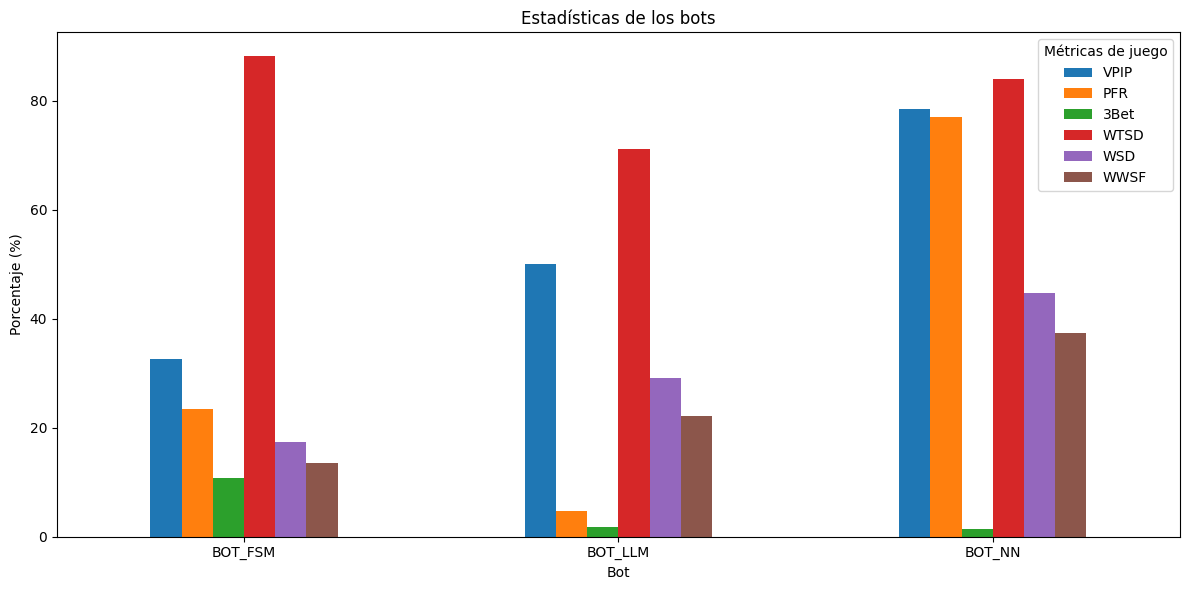

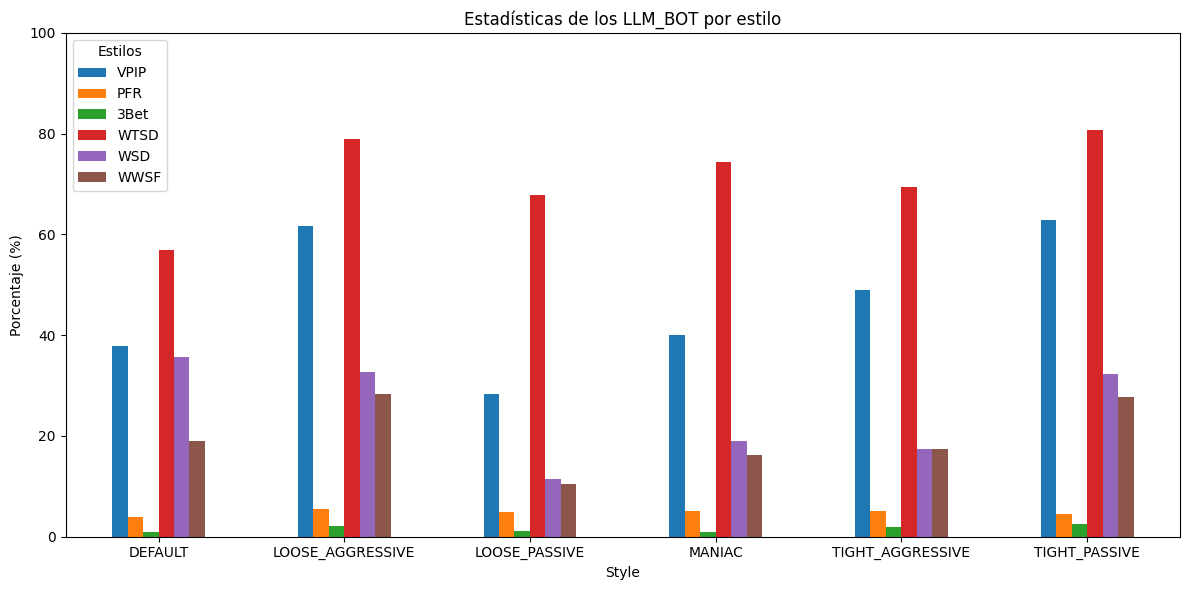

In [42]:
dist_bots_completa()
dist_llm_style()

## Pregunta 1 - ¿Qué bot tiene mejores resultados?
- Win Rate, chips, manos hasta ganar, supervivencia y consistencia
- Comparar LLM, wRed Neuronal y FSM
- Dentro de los LLM, comparar también los distintos estilos
- Gráficas: Barras + BoxPlot

In [43]:
### WINRATE POR TIPO DE BOT ###
def winrate_bots():
    
    win_rate = (
        all_bot_data
        .groupby('Type')['Hand result']
        .apply(lambda x: (x == 'WON').mean() * 100)
        .sort_values(ascending=False)
    )

    # Gráfico
    plt.figure(figsize=(10, 6))
    plt.bar(win_rate.index, win_rate.values)

    plt.xlabel('Tipo de bot')
    plt.ylabel('Win Rate (%)')
    plt.title('Win Rate por tipo de bot')
    plt.ylim(0, 100)

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "win_rate_por_bot.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

### WINRATE DE LLMS POR ESTILO ###
def winrate_llm_style():

    # Winrate de LLMs por estilo
    llm_data = all_bot_data[all_bot_data['Type'] == 'BOT_LLM']
    win_rate = (
        llm_data.groupby('Style')['Hand result']
        .apply(lambda x: (x == 'WON').mean() * 100)
    )

    plt.figure(figsize=(10, 6))

    bars = plt.bar(win_rate.index, win_rate.values)

    plt.xlabel('Style')
    plt.ylabel('Win Rate (%)')
    plt.title('Win Rate de los LLM por estilo')
    plt.ylim(0, 100)

    # Mostrar porcentaje encima de cada barra
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f'{height:.2f}%',
            ha='center'
        )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "win_rate_llm_por_style.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

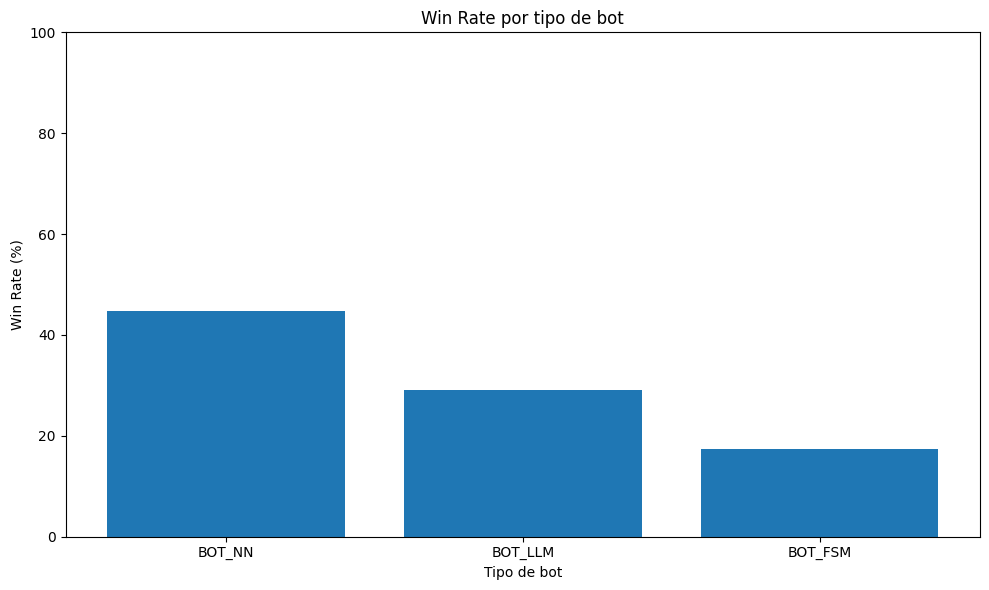

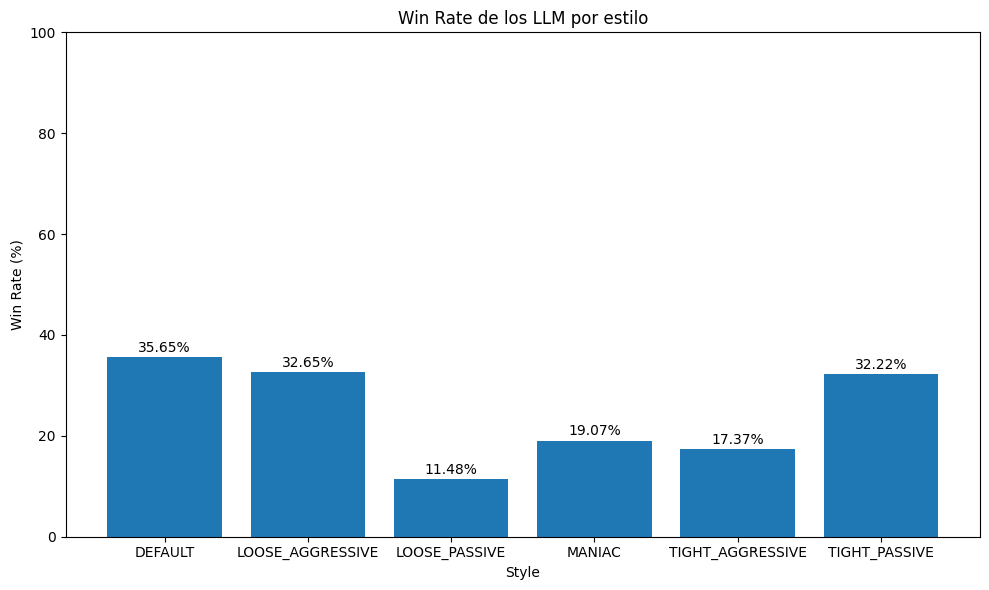

In [44]:
winrate_bots()
winrate_llm_style()

## Pregunta 2 - ¿La agresividad mejora los resultados?
- Nº de All-ins, % ganados/perdidos, calle del All-in y equity al hacer All-in , que bot elimina mas jugadores
- Comparar LLM Local, LLM Online, Red Neuronal y FSM
- Dentro de los LLM, comparar también los distintos estilos
- Gráficas: Barras apiladas + Scatter. graficas de quesitos

In [45]:
### ALL-INS DE BOTS POR TIPO ###
def allins_bots():

    # Número de all-ins por tipo de bot
    allins = all_bot_data.groupby('Type')['AllIns'].sum()

    # Colores
    colors = plt.cm.tab10(range(len(allins)))

    # Gráfico
    plt.figure(figsize=(10, 6))

    bars = plt.bar(
        allins.index,
        allins.values,
        color=colors
    )

    plt.xlabel('Tipo de bot')
    plt.ylabel('Número de All-ins')
    plt.title('Número de All-ins por tipo de bot')

    # Valor encima de cada barra
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom'
        )

    # Leyenda
    legend_elements = [
        Patch(
            facecolor=bar.get_facecolor(),
            label=bot_type
        )
        for bar, bot_type in zip(bars, allins.index)
    ]

    plt.legend(
        handles=legend_elements,
        title='Tipo de bot'
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "allins_por_bot.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

### ALL-INS DE LLMS POR ESTILO ###
def allins_llms():

    # Solo LLM
    llm_data = all_bot_data[
        all_bot_data['Type'] == 'BOT_LLM'
    ]

    # Número de all-ins por estilo
    allins = llm_data.groupby('Style')['AllIns'].sum()

    # Colores
    colors = plt.cm.tab10(range(len(allins)))

    # Gráfico
    plt.figure(figsize=(10, 6))

    bars = plt.bar(
        allins.index,
        allins.values,
        color=colors
    )

    plt.xlabel('Style')
    plt.ylabel('Número de All-ins')
    plt.title('Número de All-ins de los LLM por estilo')

    # Valor encima de cada barra
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom'
        )

    # Leyenda
    legend_elements = [
        Patch(
            facecolor=bar.get_facecolor(),
            label=style
        )
        for bar, style in zip(bars, allins.index)
    ]

    plt.legend(
        handles=legend_elements,
        title='Style'
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "allins_llm_por_style.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

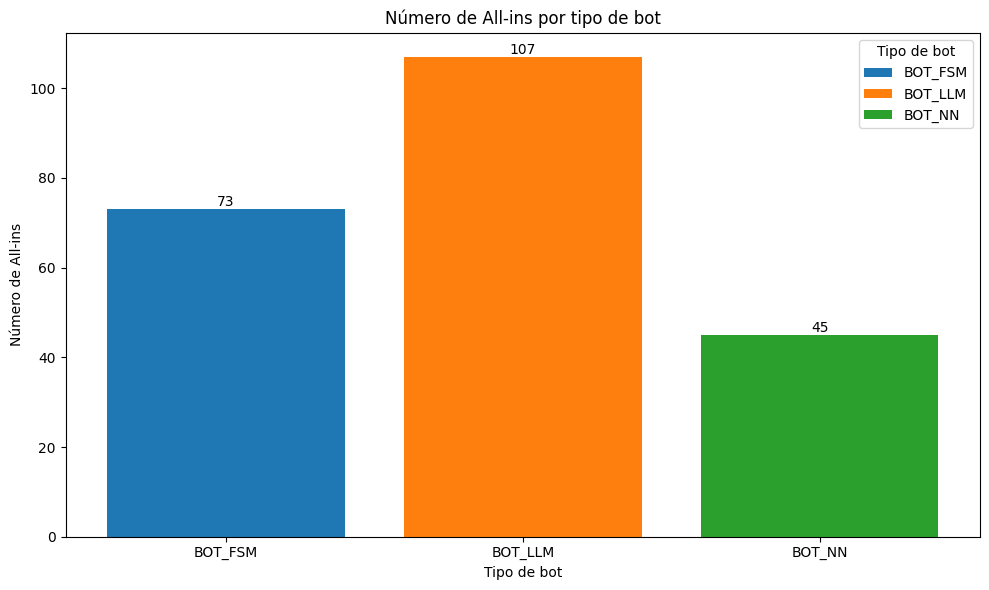

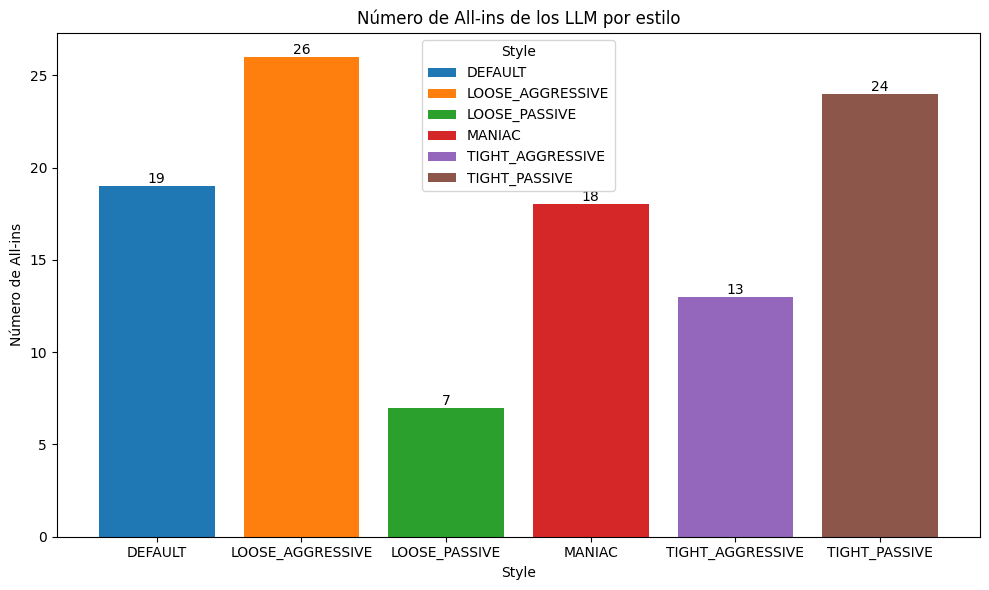

In [46]:
allins_bots()
allins_llms()

## Pregunta 3 - ¿Qué decisiones tienen mayor impacto en el resultado?
- Acción realizada
- Equity
- Comparar Fold, Call, Raise y All-in
- Gráficas: Barras comparativas + Grafica de quesitos

## Pregunta 4 - ¿Cómo evoluciona el bot durante la partida?
- Evolución del stack.
- Win Rate por bloques de manos.
- Equity por bloques.
- Evolución de VPIP/AF.
- Tiempo como líder.
- Gráficas: Líneas + Barras graficas de columnas y lineas

## Pregunta 5 - ¿Cómo consigue ganar cada bot?
- Manos hasta ganar
- Eliminaciones
- All-ins por victoria
- Fold del rival
- Showdown
- All-in
- Gráficas: Variadas

## Pregunta 6 - ¿Influye el tipo de partida?
- Heads-Up vs Humanos + Bots vs Solo Bots.
- Rendimiento, comportamiento, All-ins, manos hasta ganar y equity.
- Gráficas: Barras.

Y de todo esto podemos sacar las preguntas más interesantes:
- ¿Qué bot gana más rápido?
- ¿Qué bot hace más All-ins?
- ¿Qué bot acierta más cuando hace All-in?
- ¿Qué bot toma mejores decisiones?
- ¿Qué decisiones generan más ganancias o pérdidas?
- ¿Qué bot remonta mejor?
- ¿Qué bot lidera durante más tiempo?

¿Qué bot elimina más jugadores?
- Comparar LLM Local, LLM Online, Red Neuronal y FSM.
- Dentro de los LLM, comparar también los distintos estilos

- ¿Qué bot es más consistente?
- ¿El bot mejora durante la partida?
- ¿Cómo gana cada bot?
- ¿La equity se traduce realmente en mejores resultados?
- ¿Tomar más riesgos aumenta las posibilidades de ganar?

# Análisis específico

## Pregunta 7 - ¿Cómo cambia el bot frente a distintos niveles de jugador?
- Experimento: Humano vs Bot — Heads-Up .
- Comparar: Principiante vs Intermedio vs Profesional.
- Datos: Win Rate, chips, VPIP, PFR, AF, All-ins y equity.
- Gráficas: Barra + Lineas grafica combinada

## Pregunta 8 - ¿Cómo se comportan los bots en una mesa con humanos?
- Experimento: 2 humanos principiantes + Gemini + Ollama + NN + FSM.
- Datos: Evolución del stack, Win Rate, VPIP, AF y eliminaciones.
- Gráficas: Líneas + Barras apiladas.

## Pregunta 9 - ¿Los estilos realmente cambian el comportamiento del mismo modelo?
- Experimento: 6 Ollama con estilos mixtos.
- Comparar: DEFAULT, TP, TAG, LP, LAG y MANIAC.
- Datos: VPIP, PFR, 3Bet, AF, Win Rate, chips y All-ins.
- Gráficas: Radar

## Pregunta 10 - ¿Cómo compite el LLM contra NN y FSM?
- Experimento: Bot vs Bot.
- Comparar: Ollama DEFAULT, TP y LAG frente a NN/FSM.
- Datos: Win Rate, chips, equity, AF y All-ins.
- Gráficas: Heatmap + Barras.